# Dynamic Prediction System: For AirBnb's 

This model will be trained on the data taken from kaggle, the data chosen is of USA, and based on the all the training of the data with various model and predictions the best model to perform will be used to give an output which can help the host to select the best price range for their listing, based on the Location and many other factors.

In [154]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.preprocessing import StandardScaler
from warnings import filterwarnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
filterwarnings('ignore')

In [119]:
Dataset = pd.read_csv('Data/Data.csv')

In [120]:
Dataset.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,38585,Charming Victorian home - twin beds + breakfast,165529,Evelyne,NaN,28804,35.65146,-82.62792,Private room,60,1,138,16/02/20,1.14,1,0,Asheville
1,80905,French Chic Loft,427027,Celeste,NaN,28801,35.59779,-82.55540,Entire home/apt,470,1,114,07/09/20,1.03,11,288,Asheville
2,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,320564,Lisa,NaN,28801,35.60670,-82.55563,Entire home/apt,75,30,89,30/11/19,0.81,2,298,Asheville
3,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.57864,-82.59578,Entire home/apt,90,1,267,22/09/20,2.39,5,0,Asheville
4,160594,Historic Grove Park,769252,Elizabeth,NaN,28801,35.61442,-82.54127,Private room,125,30,58,19/10/15,0.52,1,0,Asheville


In [66]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226030 entries, 0 to 226029
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              226030 non-null  int64  
 1   name                            226002 non-null  object 
 2   host_id                         226030 non-null  int64  
 3   host_name                       225997 non-null  object 
 4   neighbourhood_group             110185 non-null  object 
 5   neighbourhood                   226030 non-null  object 
 6   latitude                        226030 non-null  float64
 7   longitude                       226030 non-null  float64
 8   room_type                       226030 non-null  object 
 9   price                           226030 non-null  int64  
 10  minimum_nights                  226030 non-null  int64  
 11  number_of_reviews               226030 non-null  int64  
 12  last_review     

In [177]:
Dataset['city'].unique()

array(['Asheville', 'Austin', 'Boston', 'Broward County', 'Cambridge',
       'Chicago', 'Clark County', 'Columbus', 'Denver', 'Hawaii',
       'Jersey City', 'Los Angeles', 'Nashville', 'New Orleans',
       'New York City', 'Oakland', 'Pacific Grove', 'Portland',
       'Rhode Island', 'Salem', 'San Clara Country', 'San Diego',
       'San Francisco', 'San Mateo County', 'Santa Cruz County',
       'Seattle', 'Twin Cities MSA', 'Washington D.C.'], dtype=object)

In [178]:
Dataset['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Hotel room', 'Shared room'],
      dtype=object)

In [121]:
Dataset.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='object')

In [122]:
dropping = ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group','last_review', 'reviews_per_month' ]

In [123]:
Dataset = Dataset.drop(dropping, axis = 1)

In [124]:
Dataset.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,city
0,28804,35.65146,-82.62792,Private room,60,1,138,1,0,Asheville
1,28801,35.59779,-82.55540,Entire home/apt,470,1,114,11,288,Asheville
2,28801,35.60670,-82.55563,Entire home/apt,75,30,89,2,298,Asheville
3,28806,35.57864,-82.59578,Entire home/apt,90,1,267,5,0,Asheville
4,28801,35.61442,-82.54127,Private room,125,30,58,1,0,Asheville


In [125]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226030 entries, 0 to 226029
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   neighbourhood                   226030 non-null  object 
 1   latitude                        226030 non-null  float64
 2   longitude                       226030 non-null  float64
 3   room_type                       226030 non-null  object 
 4   price                           226030 non-null  int64  
 5   minimum_nights                  226030 non-null  int64  
 6   number_of_reviews               226030 non-null  int64  
 7   calculated_host_listings_count  226030 non-null  int64  
 8   availability_365                226030 non-null  int64  
 9   city                            226030 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 17.2+ MB


In [126]:
Dataset.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,226030.000000,226030.000000,226030.000000,2.260300e+05,226030.000000,226030.000000,226030.000000
mean,35.662829,-103.220662,219.716529,4.525490e+02,34.506530,16.698562,159.314856
std,6.849855,26.222091,570.353609,2.103376e+05,63.602914,51.068966,140.179628
min,18.920990,-159.714900,0.000000,1.000000e+00,0.000000,1.000000,0.000000
25%,32.761783,-118.598115,75.000000,1.000000e+00,1.000000,1.000000,0.000000
50%,37.261125,-97.817200,121.000000,2.000000e+00,8.000000,2.000000,140.000000
75%,40.724038,-76.919323,201.000000,7.000000e+00,39.000000,6.000000,311.000000
max,47.734620,-70.995950,24999.000000,1.000000e+08,966.000000,593.000000,365.000000


In [127]:
Dataset.isnull().sum()

neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
city                              0
dtype: int64

In [128]:
Dataset.columns

Index(['neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='object')

Now lets check for the Exploratory Data Analysis (EDA) and see what kind of impact the numerical values have on the price and which columns to opt for and use in order to train the model.

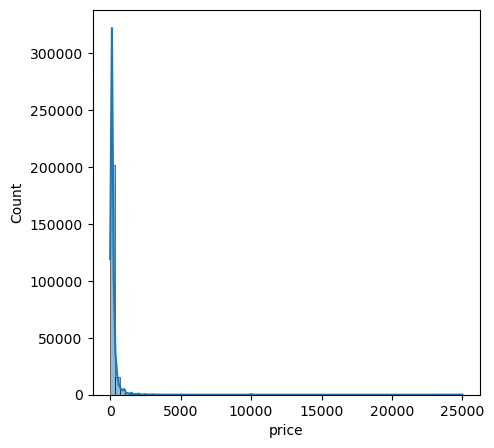

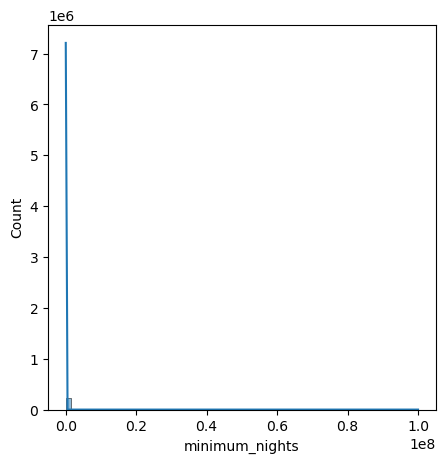

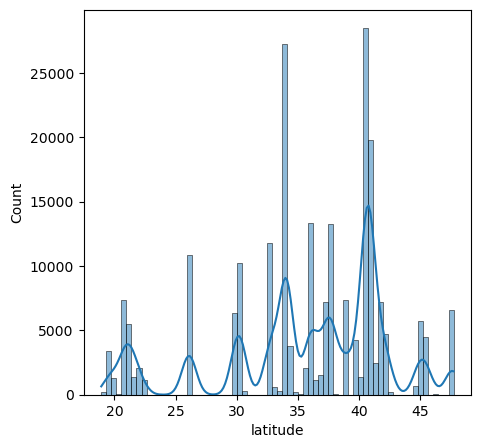

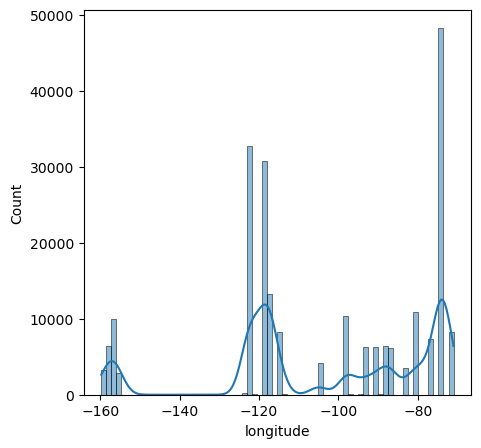

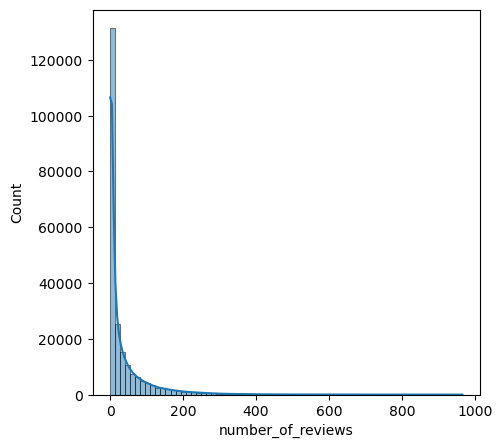

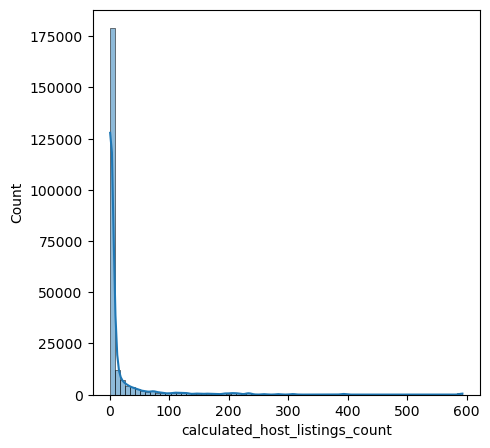

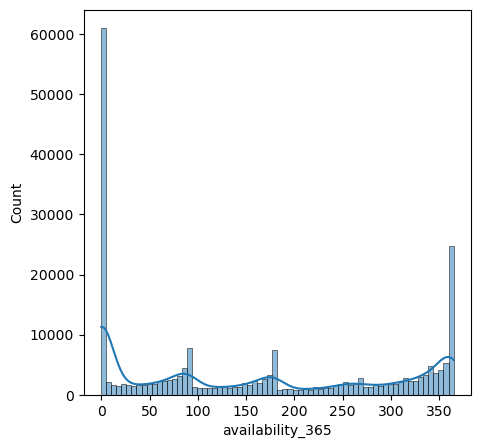

In [129]:
numeric = ['price',	'minimum_nights',	'latitude', 'longitude', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

for n in numeric:
    plt.figure(figsize=(5,5))
    sns.histplot(Dataset[n], kde = True, bins=70)

Now after this we will check for the outliers using the box plots, as in Airbnb's case their are majority of budget homes whereas a few luxury homes as outliers.

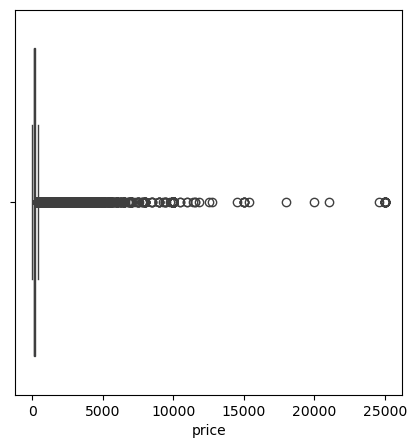

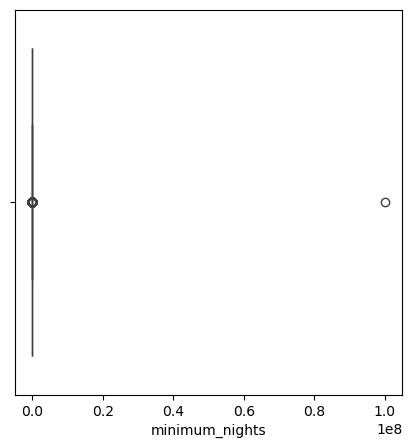

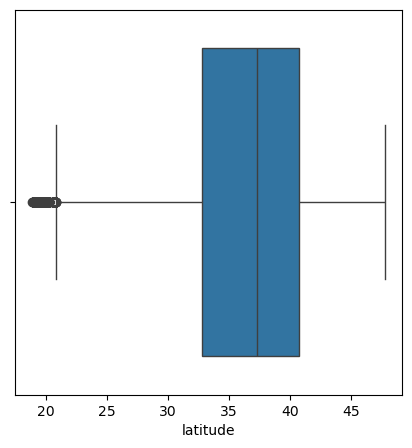

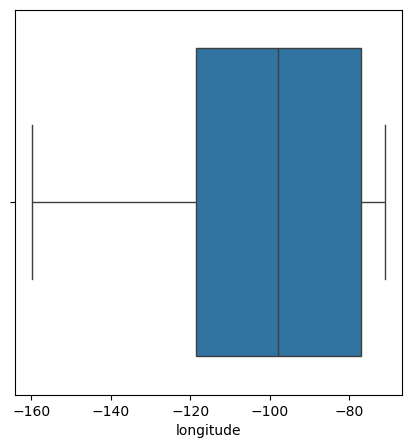

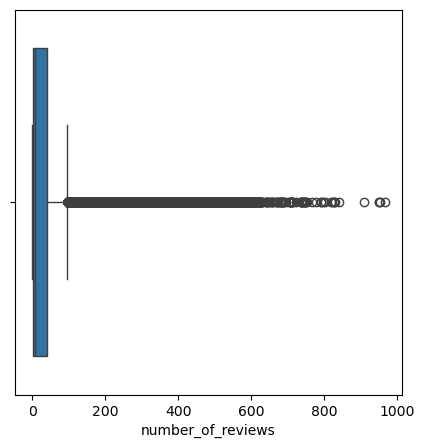

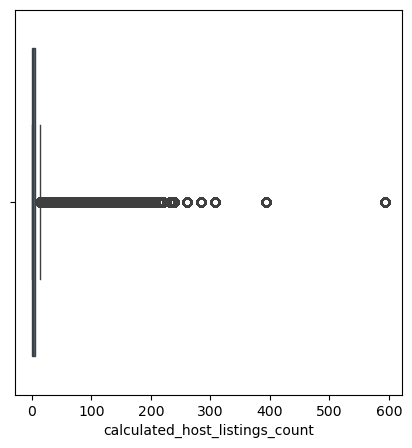

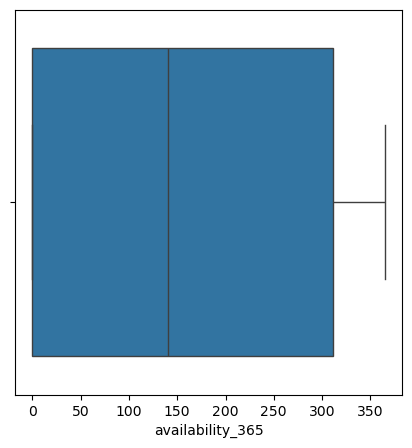

In [130]:
for plots in numeric:
    plt.figure(figsize=(5,5))
    sns.boxplot(x = Dataset[plots])

In [131]:
Dataset_copy = Dataset.copy()

In [132]:
for cols in numeric:
    Dataset_copy[f'log{cols}'] = np.log1p(Dataset[cols])

In [133]:
Dataset.columns

Index(['neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='object')

In [134]:
Dataset_copy.columns

Index(['neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'city', 'logprice', 'logminimum_nights',
       'loglatitude', 'loglongitude', 'lognumber_of_reviews',
       'logcalculated_host_listings_count', 'logavailability_365'],
      dtype='object')

Now I will be converting the numeric columns to log values in order to plot a better and much clearer picture which will somewhere have less or no outliers as compared to the numeric values.  

In [135]:
log_numeric = ['logprice', 'logminimum_nights',
       'loglatitude', 'loglongitude', 'lognumber_of_reviews',
       'logcalculated_host_listings_count', 'logavailability_365']

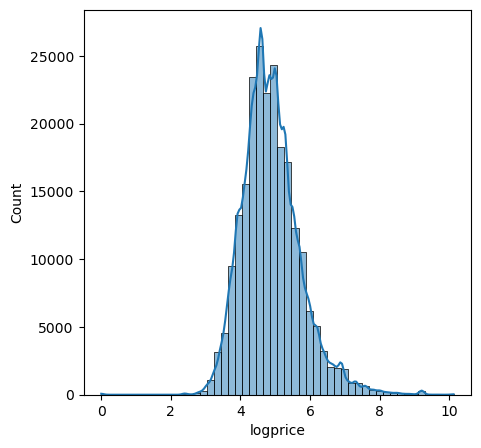

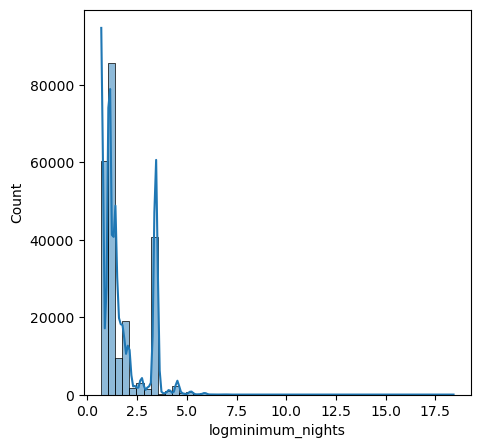

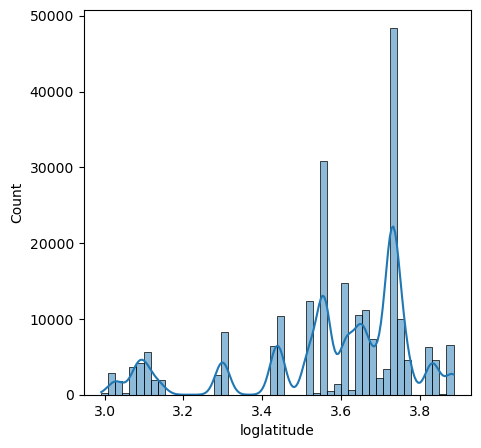

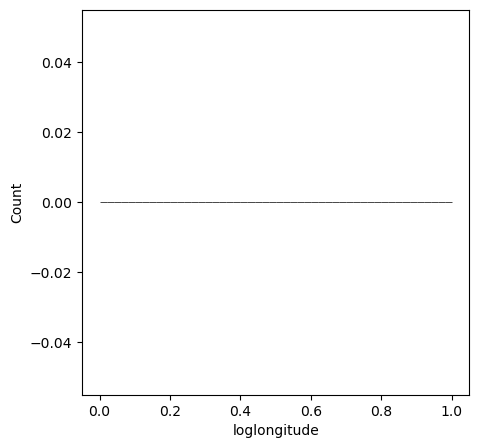

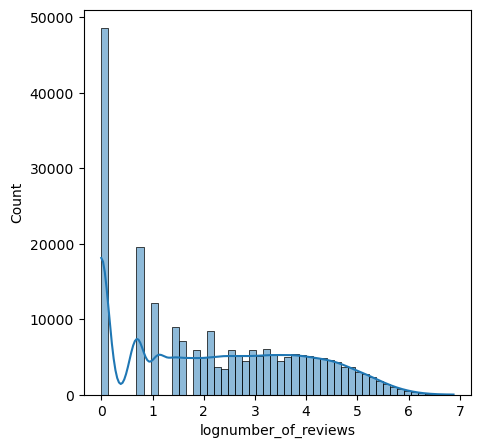

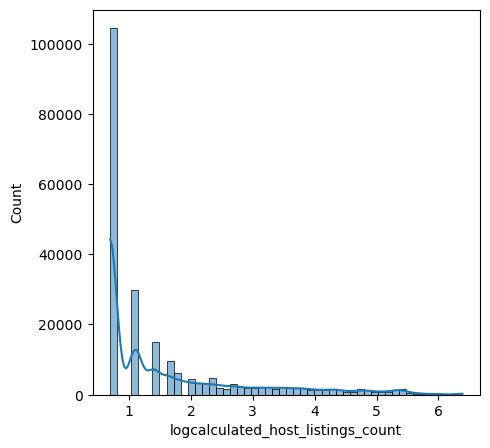

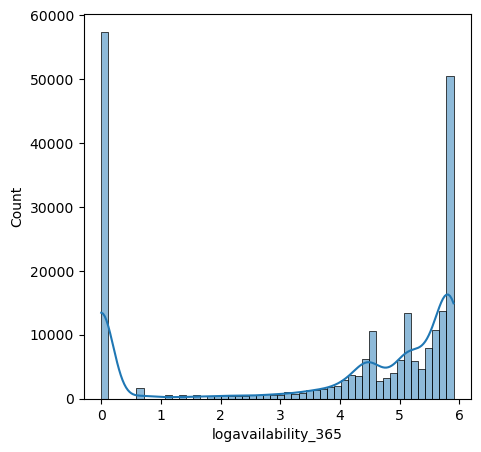

In [136]:
for n in log_numeric:
    plt.figure(figsize=(5,5))
    sns.histplot(Dataset_copy[n], kde = True, bins=50)

Now this does gives me a better approach for the EDA and to see where is the data distributed. Further I am plotting a heat map to check for the correlation of these tables with the price

<Axes: >

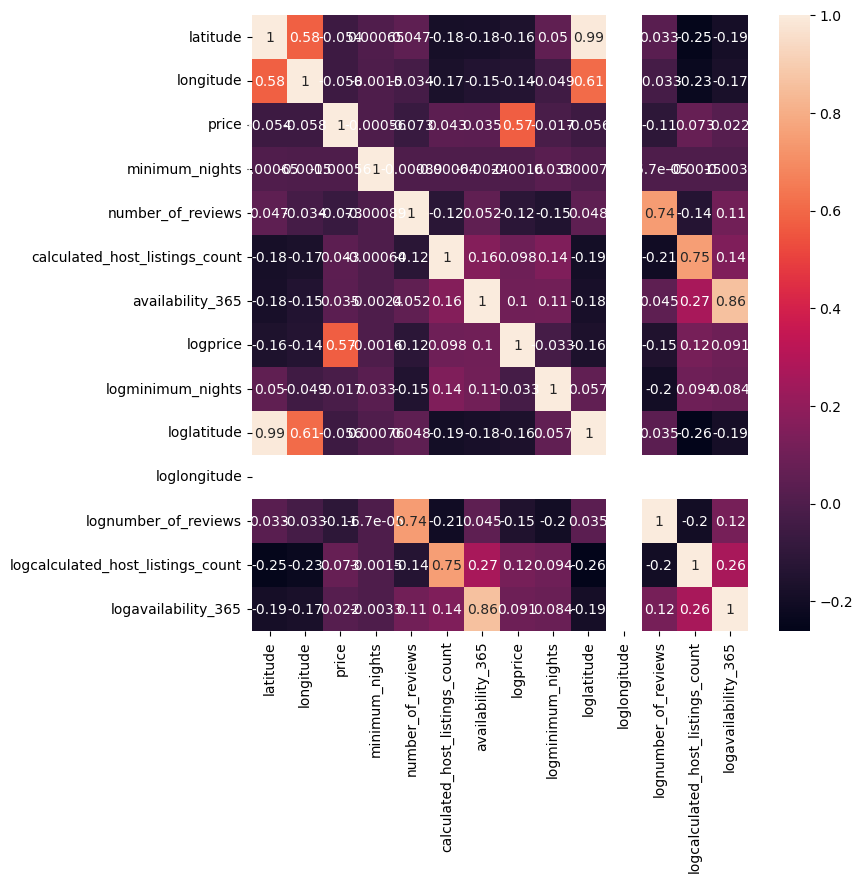

In [137]:
plt.figure(figsize = (8,8))
sns.heatmap(Dataset_copy.corr(numeric_only = True), annot = True)

Now correlation heatmap shows that numeric features alone have a very weak correlation with respect to price. Host listings count has some tiny effect so as for the availabilty, but categorical features like room type and neighbourhood might dominate pricing. Therefore, to check if these categorical features have a price effect we need to encode them and this is a critical step for modeling.

In [138]:
Dataset.columns

Index(['neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='object')

Now we will pursue with 1 hot encoding for the cities and the room type, which is neccesary as it will give us all the data that is required in the format of 1 and 0 for the different cities.

In [139]:
Dataset.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,city
0,28804,35.65146,-82.62792,Private room,60,1,138,1,0,Asheville
1,28801,35.59779,-82.55540,Entire home/apt,470,1,114,11,288,Asheville
2,28801,35.60670,-82.55563,Entire home/apt,75,30,89,2,298,Asheville
3,28806,35.57864,-82.59578,Entire home/apt,90,1,267,5,0,Asheville
4,28801,35.61442,-82.54127,Private room,125,30,58,1,0,Asheville


In [88]:
# For the better R2 lets start with the feature engineering, for the first phase I need to have the have the outliers removed 

In [148]:
Dataset = Dataset[Dataset['price'] > 0]
Dataset = Dataset[Dataset['price'] < Dataset['price'].quantile(0.99)]
Dataset = Dataset[Dataset['minimum_nights'] < 365]
Dataset = Dataset[Dataset['price'] < 1000]   # try this

In [149]:
Dataset.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,city
0,28804,35.65146,-82.62792,Private room,60,0.693147,4.934474,0.693147,0,Asheville
1,28801,35.59779,-82.55540,Entire home/apt,470,0.693147,4.744932,2.484907,288,Asheville
2,28801,35.60670,-82.55563,Entire home/apt,75,3.433987,4.499810,1.098612,298,Asheville
3,28806,35.57864,-82.59578,Entire home/apt,90,0.693147,5.590987,1.791759,0,Asheville
4,28801,35.61442,-82.54127,Private room,125,3.433987,4.077537,0.693147,0,Asheville


In [150]:
# Now lets log transform the skewed features in order to make sure that these features dont interefere with the model training and then create an issue with the prediction

Dataset['minimum_nights'] = np.log1p(Dataset['minimum_nights'])
Dataset['number_of_reviews'] = np.log1p(Dataset['number_of_reviews'])
Dataset['calculated_host_listings_count'] = np.log1p(Dataset['calculated_host_listings_count'])

Now this time I will perform the train test split first rather than the rest feature scaling 

In [152]:
X = Dataset.drop('price', axis=1)
y = Dataset['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Now lets fix the neighbourhood prices as the differnces is really vast and the values are really long approx 1450 so we cannot 1 hot or label encode it but instead do a target encoding, and then replace the whole neighbourhood column

In [153]:
TrainingDataset = X_train.copy()
TrainingDataset['price'] = y_train

NeighbourhoodMean = TrainingDataset.groupby('neighbourhood')['price'].mean()

X_train['Encoded_Neighbourhood'] = X_train['neighbourhood'].map(NeighbourhoodMean)
X_test['Encoded_Neighbourhood'] = X_test['neighbourhood'].map(NeighbourhoodMean)


GlobalMean = y_train.mean()

X_train['Encoded_Neighbourhood'].fillna(GlobalMean, inplace=True)
X_test['Encoded_Neighbourhood'].fillna(GlobalMean, inplace=True)


X_train.drop('neighbourhood', axis=1, inplace=True)
X_test.drop('neighbourhood', axis=1, inplace=True)

In [155]:
kmeans = KMeans(n_clusters=50, random_state=42)
X_train['location_cluster'] = kmeans.fit_predict(X_train[['latitude', 'longitude']])

In [157]:
X_test['location_cluster'] = kmeans.predict(X_test[['latitude', 'longitude']])

In [156]:
X_train

,latitude,longitude,room_type,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,city,Encoded_Neighbourhood,location_cluster
191610,32.86233,-117.24151,Entire home/apt,0.526589,1.397363,0.526589,206,San Diego,318.951378,19
56959,20.71145,-156.44565,Entire home/apt,0.526589,0.000000,1.634547,158,Hawaii,233.358696,21
158811,40.77166,-73.92008,Entire home/apt,0.741276,0.526589,0.526589,81,New York City,93.430657,33
194393,37.77480,-122.42711,Entire home/apt,1.489299,1.385227,0.526589,91,San Francisco,191.639798,36
224440,38.91621,-77.02893,Entire home/apt,0.741276,1.555545,1.675938,95,Washington D.C.,163.902062,12
...,...,...,...,...,...,...,...,...,...,...
122939,40.74038,-73.87599,Entire home/apt,1.291725,1.574565,0.741276,130,New York City,65.882927,40
106545,36.22478,-86.75916,Entire home/apt,0.526589,1.528427,0.526589,0,Nashville,146.054054,3
135073,40.67156,-73.98366,Entire home/apt,0.959135,1.343703,0.526589,0,New York City,165.925000,1
150130,40.77667,-73.97945,Entire home/apt,1.489299,0.000000,1.080418,365,New York City,169.973251,33


Now after the split is done and the large values of the dataset in the neighbourhood is taken care of lets begin with feature scaling for X

In [158]:
X_train = pd.get_dummies(X_train, columns=['city', 'room_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['city', 'room_type'], drop_first=True)
X_train = pd.get_dummies(X_train, columns=['location_cluster'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['location_cluster'], drop_first=True)


X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [159]:
X_train

,latitude,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,Encoded_Neighbourhood,city_Austin,city_Boston,city_Broward County,...,location_cluster_40,location_cluster_41,location_cluster_42,location_cluster_43,location_cluster_44,location_cluster_45,location_cluster_46,location_cluster_47,location_cluster_48,location_cluster_49
191610,32.86233,-117.24151,0.526589,1.397363,0.526589,206,318.951378,False,False,False,...,False,False,False,False,False,False,False,False,False,False
56959,20.71145,-156.44565,0.526589,0.000000,1.634547,158,233.358696,False,False,False,...,False,False,False,False,False,False,False,False,False,False
158811,40.77166,-73.92008,0.741276,0.526589,0.526589,81,93.430657,False,False,False,...,False,False,False,False,False,False,False,False,False,False
194393,37.77480,-122.42711,1.489299,1.385227,0.526589,91,191.639798,False,False,False,...,False,False,False,False,False,False,False,False,False,False
224440,38.91621,-77.02893,0.741276,1.555545,1.675938,95,163.902062,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122939,40.74038,-73.87599,1.291725,1.574565,0.741276,130,65.882927,False,False,False,...,True,False,False,False,False,False,False,False,False,False
106545,36.22478,-86.75916,0.526589,1.528427,0.526589,0,146.054054,False,False,False,...,False,False,False,False,False,False,False,False,False,False
135073,40.67156,-73.98366,0.959135,1.343703,0.526589,0,165.925000,False,False,False,...,False,False,False,False,False,False,False,False,False,False
150130,40.77667,-73.97945,1.489299,0.000000,1.080418,365,169.973251,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [160]:
X_test

,latitude,longitude,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,Encoded_Neighbourhood,city_Austin,city_Boston,city_Broward County,...,location_cluster_40,location_cluster_41,location_cluster_42,location_cluster_43,location_cluster_44,location_cluster_45,location_cluster_46,location_cluster_47,location_cluster_48,location_cluster_49
169063,45.47817,-122.67566,0.869742,1.560500,0.526589,15,106.380000,False,False,False,...,False,False,False,False,False,False,False,False,False,False
156520,40.83734,-73.94484,0.869742,0.526589,0.526589,0,86.544901,False,False,False,...,False,False,False,False,False,False,False,False,False,False
160443,40.60073,-73.75748,0.526589,0.741276,0.741276,180,142.407407,False,False,False,...,True,False,False,False,False,False,False,False,False,False
12465,30.28601,-97.71079,1.489299,0.000000,1.999705,300,189.656442,True,False,False,...,False,False,False,False,False,False,False,False,False,False
63764,19.71946,-155.09930,1.474144,0.869742,0.526589,364,137.161994,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188655,32.76066,-117.13001,0.741276,0.869742,0.526589,0,135.149225,False,False,False,...,False,False,False,False,False,False,False,False,False,False
67681,21.95839,-159.34714,0.526589,0.000000,1.706721,47,199.899471,False,False,False,...,False,False,False,False,False,False,False,False,False,False
177280,37.40725,-122.11267,1.489299,1.271150,0.526589,286,141.994286,False,False,False,...,False,False,False,True,False,False,False,False,False,False
216479,44.95570,-93.21971,0.741276,1.080418,0.526589,179,213.936090,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [163]:
# now the next step after splitting the data is to check for the models which will perform better and will show us better accuracy 

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

For this project I will use 
- Linear Regression
- SVM
- KNN


`` on the scaled data set `` 

- Gradient Boosting 
- XGBoost 
on the unscaled data set

`` then we will do all the hyper parameter tuning on it ``

In [164]:
scaled_models = {
    'LinearRegression' : LinearRegression(),
    'KNN': KNeighborsRegressor()
}



In [165]:
#Now for these models I need to use the scaling as well which we will do using standar scaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [166]:
final_result = []

In [167]:
# now I will run all the models and find their metrics 

for name, models in scaled_models.items():
    models.fit(X_train_scaled, y_train_log)
    pred = models.predict(X_test_scaled)
    scaled_pred = np.expm1(pred)
    mae = mean_absolute_error(y_test, scaled_pred)
    mse = mean_squared_error(y_test, scaled_pred)
    r2 = r2_score(y_test, scaled_pred)

    final_result.append (
        {
            'Model-Name': name,
            'MAE': round(mae, 4),
            'MSE': round(mse, 4 ),
            'R-2': round(r2, 4)
        }
    )

In [168]:
final_result

[{'Model-Name': 'LinearRegression',
  'MAE': 73.4249,
  'MSE': 16938.7236,
  'R-2': 0.222},
 {'Model-Name': 'KNN', 'MAE': 67.8152, 'MSE': 14269.5838, 'R-2': 0.3446}]

Now after the re-featuring of the data the result I have got are much better in case of linear regression and KNN, so now i will use these log values which are less skewed and the newly feature engineered data to find out the results for the ensemble models.

In [169]:
RandomForestParams = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'max_depth': [None, 10, 20, 30, 40, 60, 80],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}


RandomForest = RandomForestRegressor(random_state=42)

RandomForestTuned = RandomizedSearchCV(
    estimator=RandomForest,
    param_distributions=RandomForestParams,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

RandomForestTuned.fit(X_train, y_train_log)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30, 40, 60,
                                                      80],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 6, 8],
                                        'min_samples_split': [2, 5, 10, 15, 20],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000]},
                   random_state=42, scoring='r2')

In [171]:
GBParams = {
    'loss': ['squared_error', 'huber', 'absolute_error'],
    'n_estimators': [100, 200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

GradientBoosting = GradientBoostingRegressor(random_state=42)

GradientBoostingTuned= RandomizedSearchCV(
    estimator=GradientBoosting,
    param_distributions=GBParams,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

GradientBoostingTuned.fit(X_train, y_train_log)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.15],
                                        'loss': ['squared_error', 'huber',
                                                 'absolute_error'],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': [100, 200, 300, 500,
                                                         700],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2')

In [172]:
XGBoostParams = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1, 5],
    'reg_lambda': [0.5, 1, 1.5, 2, 5]
}


XGBoost = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

XGBoostTuned = RandomizedSearchCV(
    estimator=XGBoost,
    param_distributions=XGBoostParams,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

XGBoostTuned.fit(X_train, y_train_log)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                   param_distributions={'colsample_bylevel': [0.6, 0.8, 1.0],
                                        'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.15],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000],
                                        'reg_alpha': [0, 0.01, 0.1, 1, 5],
                                        'reg_lambda': [0.5, 1, 1.5, 2, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2')

In [173]:
def ModelEvaluation(name, model, X_test, y_test):

    predict = model.predict(X_test)
    # predictions = np.expm1(predict)

    mae = mean_absolute_error(y_test, predict)
    mse = mean_squared_error(y_test, predict)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predict)

    print("Model:", name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print("----------------------")


ModelEvaluation("Random Forest", RandomForestTuned.best_estimator_, X_test, y_test_log)

ModelEvaluation("Gradient Boosting", GradientBoostingTuned.best_estimator_, X_test, y_test_log)

ModelEvaluation("XGBoost", XGBoostTuned.best_estimator_, X_test, y_test_log)

Model: Random Forest
MAE : 0.3462180401761265
RMSE: 0.4665429819746592
R2  : 0.5947319116230252
----------------------
Model: Gradient Boosting
MAE : 0.36680486354020403
RMSE: 0.48537228907691476
R2  : 0.5613591828504083
----------------------
Model: XGBoost
MAE : 0.3600176416815008
RMSE: 0.4783218896706626
R2  : 0.5740098095987456
----------------------


In [185]:
import joblib


joblib.dump(RandomForestTuned.best_estimator_, "Models/BestModel.pkl", compress=6)
# joblib.dump(kmeans, "Models/kmeans.pkl")  
# joblib.dump(X_train.columns.tolist(), "Models/FeatureColumns.pkl")

['Models/BestModel.pkl']

In [186]:
import os
print(os.path.getsize("Models/BestModel.pkl") / (1024 * 1024), "MB")

373.86330699920654 MB


In [ ]:

joblib.dump(NeighbourhoodMean.to_dict(), "Models/NeighbourhoodMeanMap.pkl")
joblib.dump(GlobalMean, "Models/GlobalMean.pkl")

['Models/GlobalMean.pkl']

In [180]:
lat_long_map = Dataset.groupby('neighbourhood')[['latitude', 'longitude']].mean()

In [181]:
joblib.dump(lat_long_map.to_dict(), "Models/LatLongMap.pkl")

['Models/LatLongMap.pkl']

In [182]:
default_lat = Dataset['latitude'].mean()
default_long = Dataset['longitude'].mean()
joblib.dump(default_lat, "Models/DefaultLat.pkl")
joblib.dump(default_long, "Models/DefaultLong.pkl")


['Models/DefaultLong.pkl']